In [1]:
##############
## INITIATE ##
##############

## Imports
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Import modules
from f_dataset_wsi import WSIDatasetByInstance
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import slide_to_tiles_at_coordinates
from f_wsi_reader import read_slide
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles
from f_wsi_reader import select_patches_on_grid

#
###

In [3]:
###########################
## VISUALIZATION SCRIPT  ##
###########################

## Parameters
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0a93d9a674e358ba32e4e2ec320aefc5.tiff'] # PANDA example 1
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0bfe4af623f6be66a82289e411320773.tiff'] # PANDA example 2
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/TCGA/images/svs/TCGA-EJ-5509-01A_2.svs'] # TCGA
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413)/reference/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413).png'] # SEGG
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/EU_7189_16_2D_HandE_TissueTrain_(1.00,49850,30011,6780,4562)/reference/EU_7189_16_2D_HandE_TissueTrain_(1.00,49850,30011,6780,4562).png'] # SEGG
wsi_paths = ['/Users/willembonnaffe/Desktop/glandseg_examples/test/17_A047-29957_152D+-+2017-05-11+10.06.25_TissueTrain_(1.00,67585,64417,4452,4506)/reference/17_A047-29957_152D+-+2017-05-11+10.06.25_TissueTrain_(1.00,67585,64417,4452,4506).png']
#
###

(4506, 4452)


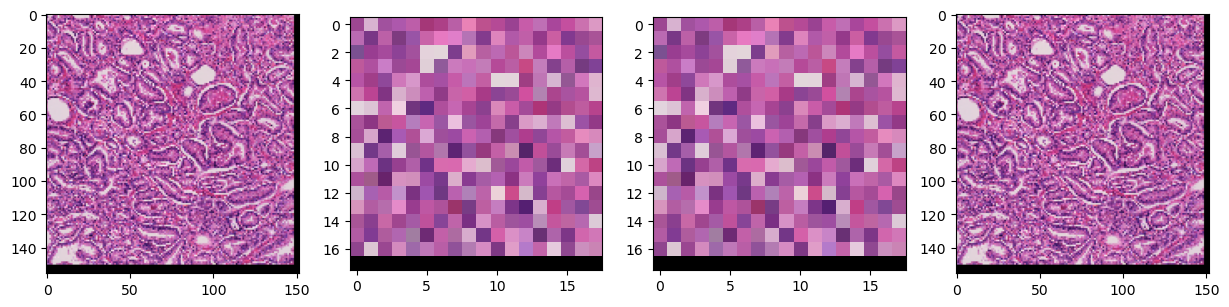

In [4]:
################## 
## GET TILE MAP ##
################## 

## Open slide
slide = read_slide(wsi_paths[0])
slide_size = get_dimensions(slide)
print(slide_size)

## Parameters
tile_size = 256

## Get tile_map
thumbnail, tile_map, canvas_size = get_tile_map(slide, tile_size)

## Extract coordinates of pixels in tile_map that contain tissue
mask = apply_all_filters(tile_map, low=10, std=15, high=200)
mask = apply_all_transforms(mask)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(mask[:,:,0].T > 0) * tile_size).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates]

## Compute mask
tile_map_masked = tile_map * mask
thumbnail_masked = thumbnail * cv2.resize(mask, (thumbnail.shape[1], thumbnail.shape[0]), cv2.INTER_LINEAR)[:,:,None]
tissue_mask = cv2.resize(mask, (slide_size[1], slide_size[0]), cv2.INTER_LINEAR)[:,:,None]

## Visualise mask
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].imshow(tile_map_masked)
axes[3].imshow(thumbnail_masked)
plt.show()
plt.close()

#
###

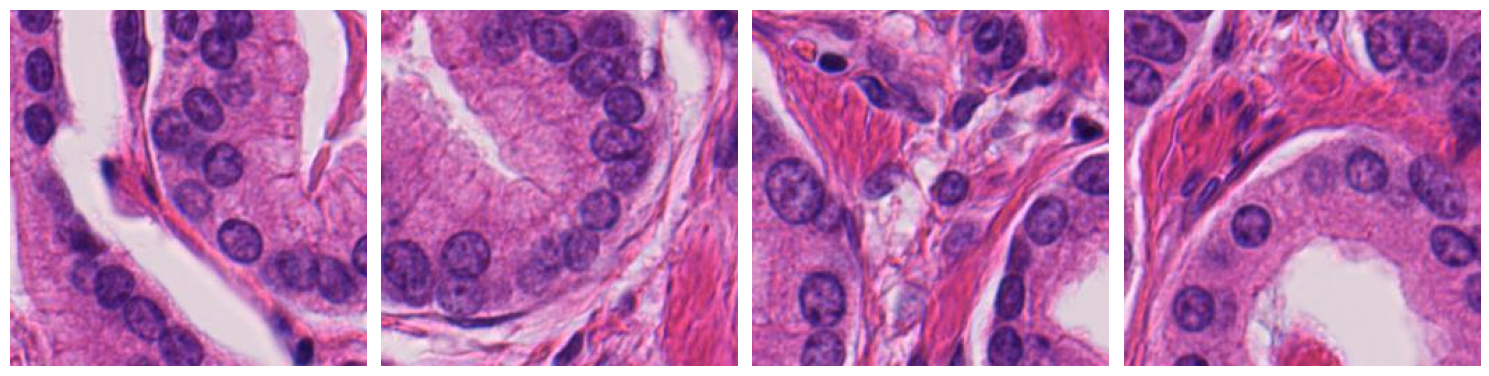

In [5]:
######################
## PATCH EXTRACTION ##
######################

## Parameters
level = 0
ds = 1
if level > 0: 
    ds = 4 * level
tile_size_ = int(tile_size/ds)# + 64
# tile_size_ = 1024

## Load patches from the dataset
patches = slide_path_to_tiles_at_coordinates(wsi_paths[0], tile_coordinates, tile_size_, level) # [dataset[i] for i in range(min(num_patches_to_display, len(dataset)))]

## Display the patches
num_patches_to_display = 4
fig, axes = plt.subplots(1, num_patches_to_display, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    if i < len(patches):
        ax.imshow(patches[i])
        ax.axis('off')
    else:
        ax.axis('off')  # Hide unused subplots if any
plt.tight_layout()
plt.show()

#
###

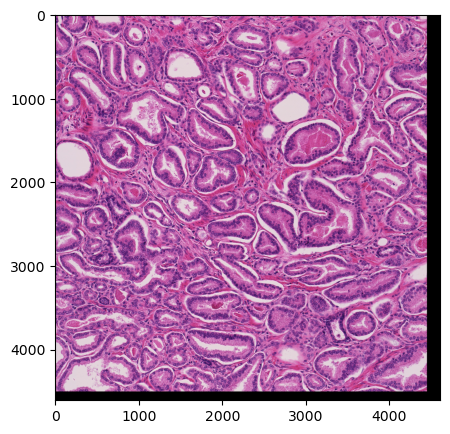

In [6]:
######################
## REASSEMBLE IMAGE ##
######################

## Convert coordinates
ds = 1
if level > 0: 
    ds = 4 * level
tile_coordinates_ds = [[int(coords_[0]/ds), int(coords_[1]/ds)] for coords_ in tile_coordinates]

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_ds, canvas_size[1], canvas_size[0])

## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(img)
# axes[1].axis('off')
# axes[2].axis('off')
# axes[3].axis('off')
plt.show()
plt.close()

#
###

64


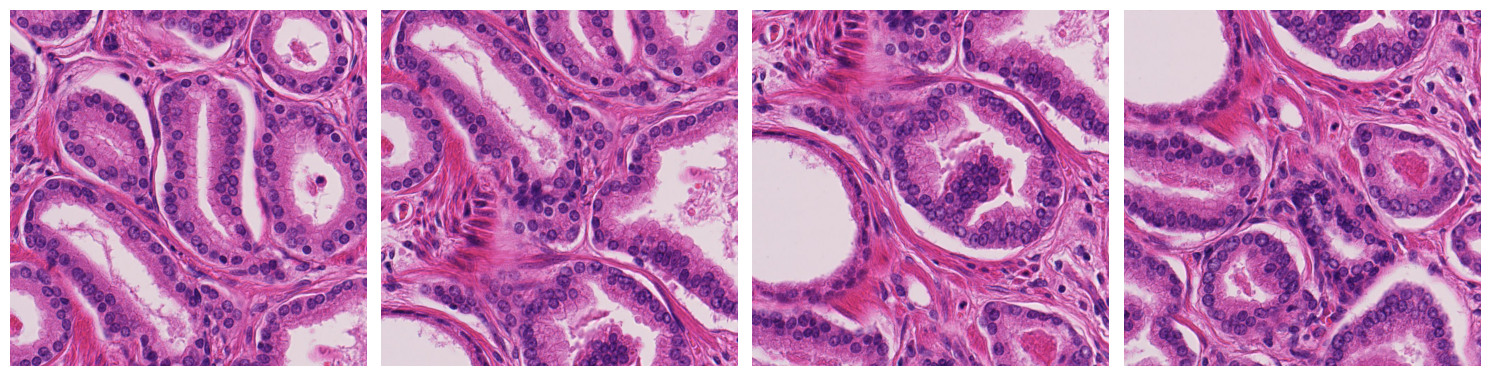

In [7]:
################################
## PATCH EXTRACTION FOR MODEL ##
################################

## Parameters
level = 0
ds = 1
if level > 0: 
    ds = 4 * level
tile_size_ = int(tile_size/ds)# + 64
tile_size_ = 1024

## Remove patches too close to the edges
tile_coordinates_ds = []
for tile_coordinates_ in tile_coordinates:
    coords_0_lo = tile_coordinates_[0] + int(tile_size/2) - int(tile_size_/2)
    coords_0_hi = tile_coordinates_[0] + int(tile_size/2) + int(tile_size_/2)
    coords_1_lo = tile_coordinates_[1] + int(tile_size/2) - int(tile_size_/2)
    coords_1_hi = tile_coordinates_[1] + int(tile_size/2) + int(tile_size_/2)
    if (coords_0_lo > 0) & (coords_0_hi < canvas_size[1]) & (coords_1_lo > 0) & (coords_1_hi < canvas_size[0]):
        tile_coordinates_ds += [[coords_0_lo, coords_1_lo]]

## Thin down coordinates
# s = np.arange(0, len(tile_coordinates_ds), 8)
# s = np.random.choice(np.arange(len(tile_coordinates_ds)), 100)
# tile_coordinates_ds = [tile_coordinates_ds[s_] for s_ in s]
tile_coordinates_ds = select_patches_on_grid(tile_coordinates_ds, grid_spacing=512)
print(len(tile_coordinates_ds))

## Load patches from the dataset
patches = slide_path_to_tiles_at_coordinates(wsi_paths[0], tile_coordinates_ds, tile_size_, level) # [dataset[i] for i in range(min(num_patches_to_display, len(dataset)))]

## Display the patches
num_patches_to_display = 4
fig, axes = plt.subplots(1, num_patches_to_display, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    if i < len(patches):
        ax.imshow(patches[i])
        ax.axis('off')
    else:
        ax.axis('off')  # Hide unused subplots if any
plt.tight_layout()
plt.show()

#
###

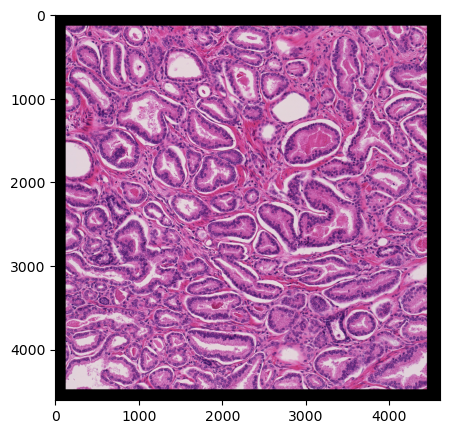

In [8]:
######################
## REASSEMBLE IMAGE ##
######################

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_ds, canvas_size[1], canvas_size[0])

## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(img)
# axes[1].axis('off')
# axes[2].axis('off')
# axes[3].axis('off')
plt.show()
plt.close()

#
###

In [9]:
#################
## APPLY MODEL ##
#################

## Imports
import numpy as np
import os
import cv2
import torch
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Import modules
# from f_dataset import SegmentationDataset

## Parameters
# batch_size = 1

## Create dataset and dataloader
# dataset = SegmentationDataset(path_to_dataset, thresholds, transform=None)
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

## Models
# from f_model import UNet as Model
# pt_model_in = 'models/r10_3.pth'
# num_classes = 4
from f_model_transformer import UNetTransformer as Model
pt_model_in = 'models/TransUNet_V2_0.pth'
num_classes = 3

## Load model
device = "mps"
print(f"Using {device} device")
model = Model(n_classes=num_classes).to(device)
if os.path.exists(pt_model_in):
    model.load_state_dict(torch.load(pt_model_in))
    print("Loaded model")

def numpy_to_device(X):
    tensors = []
    for x in X:        
        x = cv2.resize(x, (1024, 1024))        
        x = torch.tensor(x)        
        x = x.swapaxes(2, 1).swapaxes(1, 0) # (H, W, C) --> (C, H, W)
        x = x.float()
        x = x[None, :, :, :] # (C, H, W) --> (B=1, C, H, W)
        x = x.to(device)
        tensors += [x]        
    return tensors

def device_to_numpy(X):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)    
        x = x.astype('uint8')
        x = cv2.resize(x, (tile_size_, tile_size_))
        images += [x]        
    return images

## Example of iterating through the DataLoader
preds = []
k = 0
X = numpy_to_device(patches)
with torch.no_grad():
    for x in X:                
        Yhat = model(x)        
        Yhat = torch.sigmoid(Yhat) * 255 # Logits to probabilities to [0, 255]        
        Yhat = device_to_numpy(Yhat)[0] # Only for single ptch
        Yhat = np.argmax(Yhat, axis=2).reshape(Yhat.shape[0], Yhat.shape[1], 1) # Only for multiple classes
        preds += [Yhat]        

#
###

Using mps device
Loaded model


/Users/willembonnaffe/anaconda3/envs/pytorch/lib/python3.8/site-packages/torch/nn/functional.py:3959: UserWarning: MPS: passing scale factor to upsample ops is supported natively starting from macOS 13.0. Falling back on CPU. This may have performance implications. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1682343685278/work/aten/src/ATen/native/mps/operations/UpSample.mm:233.)
  return torch._C._nn.upsample_bilinear2d(input, output_size, align_corners, scale_factors)


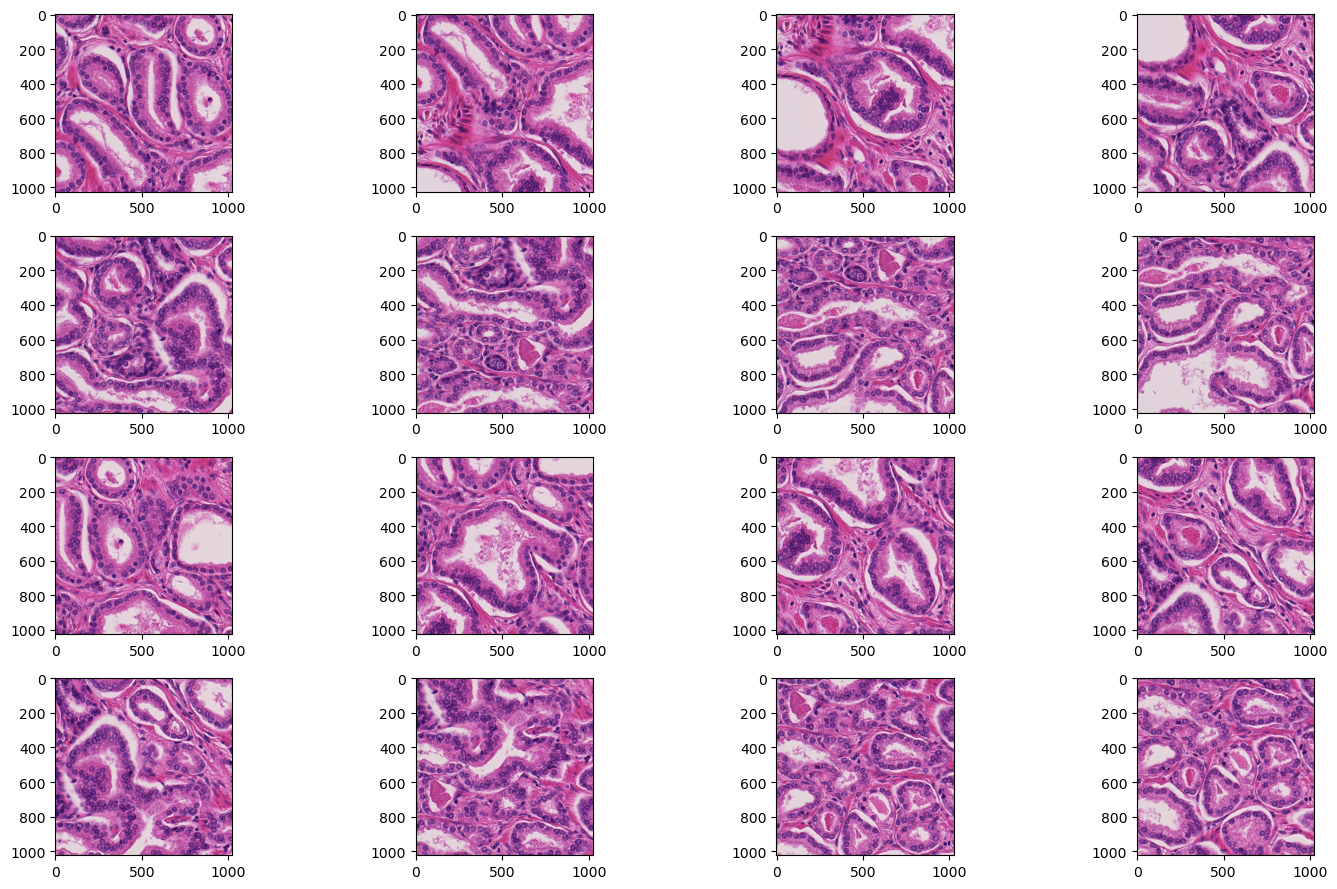

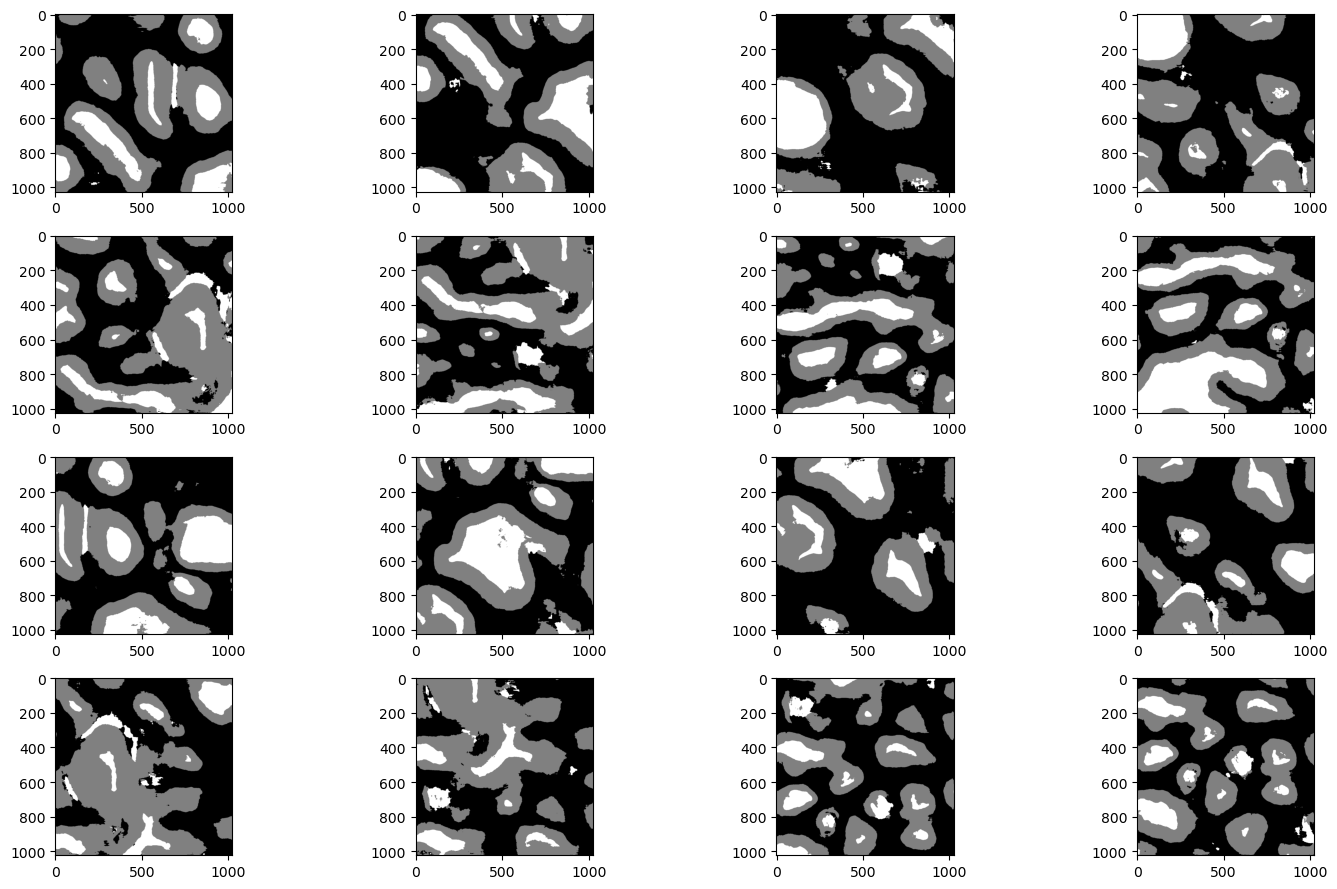

In [10]:
###########################
## VISUALISE PREDICTIONS ##
###########################

## Graphical parameters
from matplotlib.colors import ListedColormap
custom_cmap = 'gist_gray' # ListedColormap(['pink', 'hotpink', 'ivory'])

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(15,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(patches[k], cmap=custom_cmap)
        k += 1
plt.tight_layout()
plt.show()
plt.close()

## Visualise predictions
fig, axes = plt.subplots(4, 4, figsize=(15,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]
        axis.imshow(preds[k], cmap=custom_cmap)        
        k += 1
plt.tight_layout()
plt.show()
plt.close()

#
###

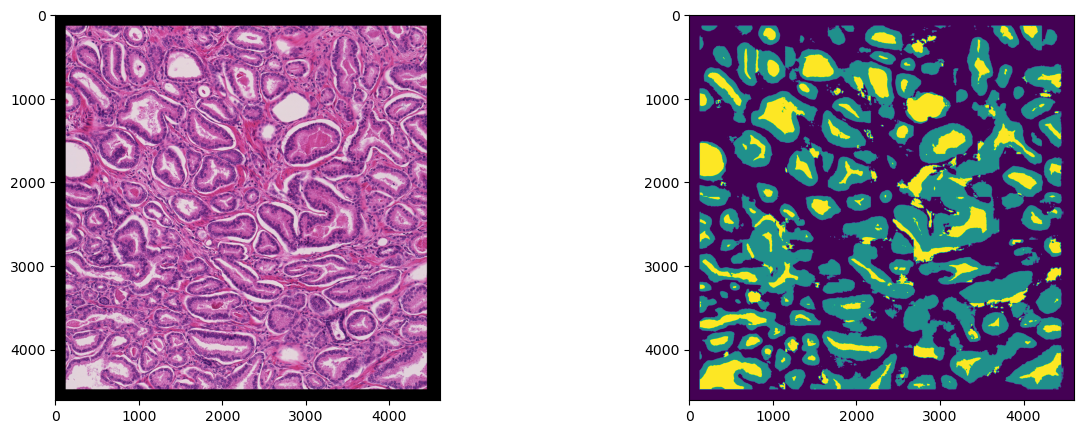

In [11]:
############################
## REASSEMBLE PREDICTIONS ##
############################

## Assemble predictions
img = reassemble_tiles(patches, tile_coordinates_ds, canvas_size[1], canvas_size[0])
mask = reassemble_tiles(preds, tile_coordinates_ds, canvas_size[1], canvas_size[0])
mask = mask[:,:,0].reshape(mask.shape[0], mask.shape[1], 1) 
mask[:tissue_mask.shape[0], :tissue_mask.shape[1]] = mask[:tissue_mask.shape[0], :tissue_mask.shape[1]] * tissue_mask

## Visualise
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(img)
axes[1].imshow(mask)
# axes[2].axis('off')
# axes[3].axis('off')
plt.show()
plt.close()

#
###

In [13]:
## get_object_centers
## goal: get centers of object coordinates list
## coordinates - list - list of object coordinates
def get_object_centers(coordinates):
    centers = []
    for i in range(len(coordinates)):
    	coordinates_i = coordinates[i].astype("int")
    	centers.append(np.round(np.mean(coordinates_i, axis=0)).astype("int"))
    centers = np.array(centers)
    return centers

## visualise_objects 
## goal: visualise individual objects in image
## img         - np.array - image as numpy array 
## coordinates - list     - list of coordinates of pixels of objects 
## pto         - string   - path to store output image
def inlay_objects(img, coordinates):
    img = img * 0
    if len(img.shape) < 3:
        img = img[:,:,None]
    if img.shape[2] == 1: 
        img = np.repeat(img, 3, axis=2)
    for i in range(len(coordinates)):
    	coordinates_i = coordinates[i].astype("int")
    	color_vect = np.random.uniform(0,1,3)*255
    	img[coordinates_i[:,0],coordinates_i[:,1],0] = color_vect[0]
    	img[coordinates_i[:,0],coordinates_i[:,1],1] = color_vect[1]
    	img[coordinates_i[:,0],coordinates_i[:,1],2] = color_vect[2]
    return img

def extract_object_pixels(mask):
    """
    Extract the pixel coordinates of objects from a binary segmentation mask.

    Parameters:
    mask (numpy.ndarray): A 2D binary segmentation mask where objects have a value of 1 (or 255) and background is 0.

    Returns:
    list: A list of numpy arrays, each containing the (row, column) coordinates of the pixels of each object.
    """
    # Ensure the mask is binary (values are either 0 or 1)
    if mask.max() > 1:
        mask = mask // 255  # Convert 255 values to 1 for consistency if it's an 8-bit mask.

    # Find connected components (objects) in the mask
    num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))

    # Extract pixel coordinates for each object, ignoring the background (label 0)
    object_pixels = []
    for label in range(1, num_labels):
        # Find pixel coordinates where the label is present
        pixels = np.column_stack(np.where(labels == label))
        object_pixels.append(pixels)

    return object_pixels

# Function to extract bounding box from object coordinates
def get_bounding_box(coords):
    """
    Get the bounding box of an object from its pixel coordinates.

    Parameters:
    coords (numpy.ndarray): Array of (row, column) coordinates of the object's pixels.

    Returns:
    tuple: Bounding box coordinates (x_min, y_min, x_max, y_max).
    """
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return x_min, y_min, x_max, y_max

In [ ]:
## Binarise mask
mask_bin = ((mask > 0)*1).astype('uint8')
mask_bin = cv2.resize(mask_bin, (int(mask_bin.shape[1]/4), int(mask_bin.shape[0]/4)))
mask_bin = mask_bin[:,:,None]

## Get objects
import time
t0 = time.time()
gland_coords = extract_object_pixels(mask_bin)
tf = time.time()
print(f'{tf-t0:.2f}s')
print(gland_coords[0])

# Rescale coordinates to original size
scale_factor = 4  # since we resized by a factor of 4 earlier
rescaled_gland_coords = [coords * scale_factor for coords in gland_coords]

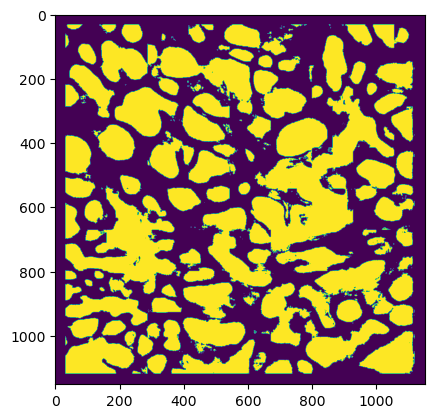

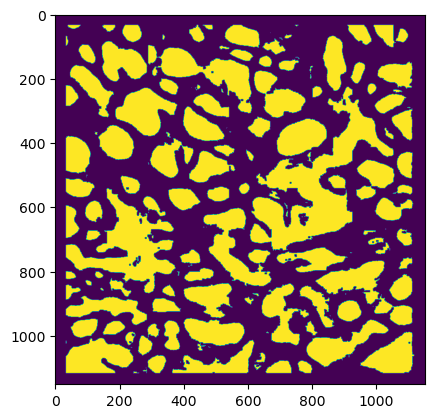

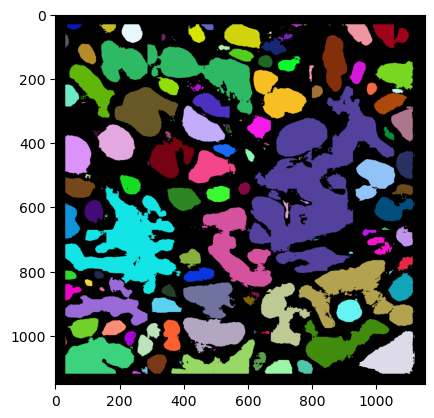

In [27]:
from f_wsi_reader import overlay_shifted_copies

## apply_all_transforms
## Goal:
## Apply various transformations to the image, including diffusion and erosion.
## Inputs:
## img (numpy array): Image to apply transformations on.
## Outputs:
## img (numpy array): Transformed image.
def polish(img):
    ## Erosion
    kernel = np.ones((5, 5), np.uint8)  # Adjust the kernel size if needed
    img = cv2.erode(img, kernel, iterations=1)
    img = img.astype(np.uint8)

    # ## Diffusion 
    # for k in range(3):
    #     img = overlay_shifted_copies(img) > 0
    # img = img.astype(np.uint8)
    # img = img.reshape(img.shape[0], img.shape[1], 1)
    
    return img

mask_ = polish(mask_bin)

plt.imshow(mask_bin)
plt.show()
plt.close()

plt.imshow(mask_)
plt.show()
plt.close()

plt.imshow(inlay_objects(mask_bin, gland_coords))
plt.show()
plt.close()

In [ ]:
# Create a folder to store extracted object images
output_folder = '/Users/willembonnaffe/Desktop/extracted_objects_2'
os.makedirs(output_folder, exist_ok=True)

# Extract and save each object
for i, coords in enumerate(rescaled_gland_coords):

    if len(coords) > 1000:
        # Get bounding box of the object
        x_min, y_min, x_max, y_max = get_bounding_box(coords)
    
        # Extract the object from the original image
        object_img = img[(y_min - 10):(y_max + 10), (x_min-10):(x_max + 10)]
    
        # Save the object image
        object_filename = os.path.join(output_folder, f'object_{i}.png')
        cv2.imwrite(object_filename, object_img)
    
        print(f'Saved object {i} to {object_filename}')

In [ ]:
import numpy as np
import cv2
import os

# Function to extract pixels of objects from a binary segmentation mask
def extract_object_pixels(mask):
    """
    Extract the pixel coordinates of objects from a binary segmentation mask.

    Parameters:
    mask (numpy.ndarray): A 2D binary segmentation mask where objects have a value of 1 (or 255) and background is 0.

    Returns:
    list: A list of numpy arrays, each containing the (row, column) coordinates of the pixels of each object.
    """
    if mask.max() > 1:
        mask = mask // 255  # Convert 255 values to 1 for consistency if it's an 8-bit mask.

    num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))

    object_pixels = []
    for label in range(1, num_labels):
        pixels = np.column_stack(np.where(labels == label))
        object_pixels.append(pixels)

    return object_pixels

## Binarise mask
mask_bin = ((mask > 0) * 1).astype('uint8')
mask_bin = cv2.resize(mask_bin, (int(mask_bin.shape[1] / 4), int(mask_bin.shape[0] / 4)))
mask_bin = mask_bin[:, :, None]

## Get objects
import time

t0 = time.time()
gland_coords = extract_object_pixels(mask_bin)
tf = time.time()
print(f'{tf - t0:.2f}s')
print(gland_coords[0])

# Rescale coordinates to original size
scale_factor = 4  # since we resized by a factor of 4 earlier
rescaled_gland_coords = [coords * scale_factor for coords in gland_coords]

In [ ]:
# Function to extract bounding box from object coordinates
def get_bounding_box(coords):
    """
    Get the bounding box of an object from its pixel coordinates, making it square.

    Parameters:
    coords (numpy.ndarray): Array of (row, column) coordinates of the object's pixels.

    Returns:
    tuple: Bounding box coordinates (x_min, y_min, x_max, y_max).
    """
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    # Calculate width and height
    width = x_max - x_min
    height = y_max - y_min
    
    # Make the bounding box square by taking the larger of the two dimensions
    side_length = max(width, height)
    
    # Center the square box around the object's bounding box
    x_center = (x_min + x_max) // 2
    y_center = (y_min + y_max) // 2
    
    x_min = x_center - side_length // 2
    x_max = x_center + side_length // 2
    y_min = y_center - side_length // 2
    y_max = y_center + side_length // 2

    return x_min, y_min, x_max, y_max

# Create a folder to store extracted object images
output_folder = '/Users/willembonnaffe/Desktop/extracted_objects'
os.makedirs(output_folder, exist_ok=True)

# Extract and save each object
for i, coords in enumerate(rescaled_gland_coords):

    if len(coords) > 1000:
        # Get bounding box of the object
        x_min, y_min, x_max, y_max = get_bounding_box(coords)
    
        # Pad the image if the bounding box is too close to the edge
        pad_value = 0  # Black padding
        pad_width = max(0, -x_min, x_max - img.shape[1] + 1)
        pad_height = max(0, -y_min, y_max - img.shape[0] + 1)
    
        # Apply padding if needed
        if pad_width > 0 or pad_height > 0:
            img_padded = cv2.copyMakeBorder(
                img,
                top=pad_height,
                bottom=pad_height,
                left=pad_width,
                right=pad_width,
                borderType=cv2.BORDER_CONSTANT,
                value=[pad_value, pad_value, pad_value]
            )
            # Adjust bounding box for the padded image
            x_min += pad_width
            x_max += pad_width
            y_min += pad_height
            y_max += pad_height
        else:
            img_padded = img
    
        # Extract the object from the padded image
        object_img = img_padded[y_min:y_max + 1, x_min:x_max + 1]
    
        # Save the object image
        object_filename = os.path.join(output_folder, f'object_{i}_mask.png')
        cv2.imwrite(object_filename, object_img)
    
        print(f'Saved object {i} to {object_filename}')

In [29]:
# Create a folder to store extracted object images
output_folder = '/Users/willembonnaffe/Desktop/extracted_objects_2'
os.makedirs(output_folder, exist_ok=True)

# Option to apply mask to the extracted images
apply_mask = True  # Set to False to disable applying the mask

# Rescale mask to the original size
mask_upscaled = cv2.resize(mask_bin, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

# Extract and save each object
for i, coords in enumerate(rescaled_gland_coords):

    if len(coords) > 1000:
        # Get bounding box of the object
        x_min, y_min, x_max, y_max = get_bounding_box(coords)
    
        # Clip the bounding box to image boundaries
        x_min_clipped = max(x_min, 0)
        y_min_clipped = max(y_min, 0)
        x_max_clipped = min(x_max, img.shape[1] - 1)
        y_max_clipped = min(y_max, img.shape[0] - 1)

        # Extract the object from the original image
        object_img = img[y_min_clipped:y_max_clipped + 1, x_min_clipped:x_max_clipped + 1]
        object_mask = mask_upscaled[y_min_clipped:y_max_clipped + 1, x_min_clipped:x_max_clipped + 1]

        # Pad the object image and mask to make them square if near the edge
        pad_width = max(0, x_max - x_max_clipped, x_min_clipped - x_min)
        pad_height = max(0, y_max - y_max_clipped, y_min_clipped - y_min)

        if pad_width > 0 or pad_height > 0:
            pad_top = max(0, y_min - y_min_clipped)
            pad_bottom = max(0, y_max - y_max_clipped)
            pad_left = max(0, x_min - x_min_clipped)
            pad_right = max(0, x_max - x_max_clipped)

            object_img = cv2.copyMakeBorder(
                object_img,
                top=pad_top,
                bottom=pad_bottom,
                left=pad_left,
                right=pad_right,
                borderType=cv2.BORDER_CONSTANT,
                value=[0, 0, 0]  # Black padding
            )
            object_mask = cv2.copyMakeBorder(
                object_mask,
                top=pad_top,
                bottom=pad_bottom,
                left=pad_left,
                right=pad_right,
                borderType=cv2.BORDER_CONSTANT,
                value=[0]  # Black padding for the mask
            )

        # Optionally apply the binary mask to the extracted object image
        if apply_mask:
            object_img = cv2.bitwise_and(object_img, object_img, mask=object_mask)

        # Save the object image
        object_filename = os.path.join(output_folder, f'object_{i}_mask.png')
        cv2.imwrite(object_filename, object_img)
    
        print(f'Saved object {i} to {object_filename}')

Saved object 2 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_2_mask.png
Saved object 3 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_3_mask.png
Saved object 5 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_5_mask.png
Saved object 11 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_11_mask.png
Saved object 12 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_12_mask.png
Saved object 26 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_26_mask.png
Saved object 29 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_29_mask.png
Saved object 33 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_33_mask.png
Saved object 35 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_35_mask.png
Saved object 38 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_38_mask.png
Saved object 43 to /Users/willembonnaffe/Desktop/extracted_objects_2/object_43_mask.png
Saved object 44 to /Users/willembonnaf

In [ ]:
############
## SHIFTS ##
############

## Tile coordinates
x_center = int(1000/(level+1))
y_center = int(1000/(level+1))
dx = dy = int(100/(level+1))
tile_coordinates = [[x_center, y_center] for _ in range(4)]
k = 0
for i in [-1, 1]:
    for j in [-1, 1]:
        tile_coordinates[k][0] = tile_coordinates[k][0] + i * dx
        tile_coordinates[k][1] = tile_coordinates[k][1] + j * dy        
        k += 1
k = 0
for i in [-1, 1]:
    for j in [-1, 1]:
        tile_coordinates[k][0] = tile_coordinates[k][0] - i * dx
        tile_coordinates[k][1] = tile_coordinates[k][1] - j * dy        
        k += 1
tile_coordinates = [tile_coordinates]

## Instantiate the dataset
dataset = WSIDatasetByInstance(
    wsi_path_list=wsi_paths,
    tile_coordinate_list=tile_coordinates,
    tile_size=tile_size,
    level=level
)

#
###